In [1]:
# Figure 3: generality / the filtering-series test (Claim 3). Soo's 61 genes are a
# strict AND across three induction experiments - does the shortage of folding
# machinery among them reflect ATFS-1 biology, or is the AND filter itself
# manufacturing it? Walk the same question back through the looser lists the 61
# were carved out of. If the artifact hypothesis were right, folding
# representation would fall as the filter tightens. Re-derives Analysis A's
# filtering-series walk (its cells 0-3 and 6) independently rather than reading a
# stored intermediate, and validates against the exact numbers already on record
# in gate_decisions.md before drawing anything.
import os
if os.path.basename(os.getcwd()) == "scripts":
    os.chdir("..")
import sys
sys.path.insert(0, "scripts")

import gzip
import pandas as pd
import numpy as np
from scipy.stats import hypergeom
import matplotlib.pyplot as plt
from figure_style import BLUE, ORANGE, GREEN, GREY, INK, FULL_W, THREEQ_W, panel_label, save

OBO = "ref_data/go/go-basic.obo"
terms, alt_id_map = {}, {}
cur = None

def _store(term):
    if term and term["id"]:
        terms[term["id"]] = term

with open(OBO) as fh:
    for line in fh:
        line = line.rstrip("\n")
        if line.startswith("["):
            _store(cur)
            cur = {"id": None, "name": None, "ns": None, "parents": set(),
                   "obsolete": False} if line == "[Term]" else None
            continue
        if cur is None or not line:
            continue
        key, _, val = line.partition(": ")
        if key == "id":
            cur["id"] = val
        elif key == "name":
            cur["name"] = val
        elif key == "namespace":
            cur["ns"] = val
        elif key == "alt_id":
            alt_id_map[val] = cur["id"]
        elif key == "is_obsolete" and val == "true":
            cur["obsolete"] = True
        elif key == "is_a":
            cur["parents"].add(val.split(" ! ")[0].strip())
        elif key == "relationship" and val.startswith("part_of "):
            cur["parents"].add(val.split()[1])
_store(cur)

_ancestor_cache = {}
def ancestors(term_id):
    if term_id in _ancestor_cache:
        return _ancestor_cache[term_id]
    _ancestor_cache[term_id] = set()
    found = set()
    for parent in terms.get(term_id, {}).get("parents", ()):
        if parent in terms:
            found.add(parent)
            found |= ancestors(parent)
    _ancestor_cache[term_id] = found
    return found

print(f"GO ontology: {len(terms):,} terms parsed")

GO ontology: 48,340 terms parsed


In [2]:
# Annotations, propagated, exactly as in analysis_a.ipynb.
GAF = "ref_data/go/wb.gaf.gz"
records = []
with gzip.open(GAF, "rt") as fh:
    for line in fh:
        if line.startswith("!"):
            continue
        f = line.rstrip("\n").split("\t")
        if len(f) < 15 or f[12] != "taxon:6239":
            continue
        records.append((f[1], f[3], f[4], f[6], f[8]))
gaf = pd.DataFrame(records, columns=["gid", "qualifier", "go_id", "evidence", "aspect"])
gaf = gaf[~gaf["qualifier"].str.startswith("NOT") & (gaf["evidence"] != "ND")]
gaf["go_id"] = gaf["go_id"].map(lambda t: alt_id_map.get(t, t))

gene_terms = {}
for gid, go_id in zip(gaf["gid"], gaf["go_id"]):
    if go_id not in terms or terms[go_id]["obsolete"]:
        continue
    gene_terms.setdefault(gid, set()).add(go_id)
    gene_terms[gid] |= ancestors(go_id)

term_genes = {}
for gid, tset in gene_terms.items():
    for term in tset:
        term_genes.setdefault(term, set()).add(gid)

CPM = "ref_data/GSE110984/GSE110984_normalized_filtered_CPM_table_VANJ_20171130.txt.gz"
expressed = set(pd.read_csv(CPM, sep="\t")["ens_gene"].dropna())
background = expressed & set(gene_terms)
print(f"Expressed background: {len(expressed):,} genes, {len(background):,} annotated")

Expressed background: 13,837 genes, 9,371 annotated


In [3]:
# The four gene sets, same nesting logic as analysis_a.ipynb: loosest (one
# condition) to strictest (Soo's 61, all three conditions plus Soo's own further
# filtering beyond the plain intersection).
ids = pd.read_csv("ref_data/c_elegans.PRJNA13758.WS285.geneIDs.txt.gz", header=None,
                  names=["taxon", "gid", "public_name", "seqname", "status", "biotype"])
seq_to_gid = {str(s).lower(): g for s, g in zip(ids["seqname"], ids["gid"]) if pd.notna(s)}

soo = pd.read_excel("data/raw/ATFS1_targets_Soo.xlsx", sheet_name="Sheet1")
soo = soo.iloc[0:64].dropna(subset=["Gene name"]).rename(columns={"Gene sequence \nname": "seqname"})
regulon_df = soo[~soo["Gene name"].isin(["hsp-6", "hsp-60"])]
regulon = {seq_to_gid[str(s).lower()] for s in regulon_df["seqname"]}
if len(regulon) != 61:
    raise RuntimeError(f"Expected 61 regulon genes, resolved {len(regulon)}.")

WU = "data/raw/wu2018_AdditionalFile2.xlsx"
sheet = lambda name: pd.read_excel(WU, sheet_name=name, header=2)
up = lambda df: set(df[df["logFC"] > 0]["ens_gene"])
nuo6_dependent = up(sheet("nuo-6")) - up(sheet("nuo-6;atfs-1"))
et_both = up(sheet("atfs-1(et15)")) & up(sheet("atfs-1(et17)"))
three_way = nuo6_dependent & et_both

GENE_SETS = {
    "nuo-6 dependent\n(1 condition)": nuo6_dependent,
    "et15 & et17\n(2 conditions)": et_both,
    "all three\nconditions": three_way,
    "Soo high-\nconfidence 61": regulon,
}
STAGE_LABELS = list(GENE_SETS)
sizes = [len(GENE_SETS[s]) for s in STAGE_LABELS]
EXPECTED_SIZES = [1673, 529, 231, 61]
if sizes != EXPECTED_SIZES:
    raise RuntimeError(f"Filtering-series sizes changed: got {sizes}, expected {EXPECTED_SIZES}.")
print("Filtering-series sizes validated:", dict(zip(STAGE_LABELS, sizes)))

Filtering-series sizes validated: {'nuo-6 dependent\n(1 condition)': 1673, 'et15 & et17\n(2 conditions)': 529, 'all three\nconditions': 231, 'Soo high-\nconfidence 61': 61}


In [4]:
# Folding-related GO category (structural: 3 current roots + all descendants, not
# a hand-picked term list - see analysis_a.ipynb for why that distinction mattered)
# and the walk function, applied to both the GO category and the Pfam census.
FOLDING_ROOTS = ["GO:0006457", "GO:0044183", "GO:0140309"]
children = {}
for term, meta in terms.items():
    for parent in meta["parents"]:
        children.setdefault(parent, set()).add(term)

def descendants(root):
    out, stack = set(), [root]
    while stack:
        for child in children.get(stack.pop(), ()):
            if child not in out:
                out.add(child)
                stack.append(child)
    return out

folding_terms = set(FOLDING_ROOTS) | {d for r in FOLDING_ROOTS for d in descendants(r)}
folding_terms = {t for t in folding_terms if not terms[t]["obsolete"]}
folding_genes = set().union(*(term_genes.get(t, set()) for t in folding_terms))

census = pd.read_csv("data/chaperone_protease_census.csv")
census_gids = {seq_to_gid[str(s).lower()] for s in census["seqname"] if str(s).lower() in seq_to_gid}

def walk_category(category_genes, universe, sets):
    out = []
    K = len(category_genes & universe)
    for label, genes in sets.items():
        q = genes & universe
        k = len(category_genes & q)
        exp = K * len(q) / len(universe)
        out.append({"stage": label, "tested": len(q), "obs": k, "exp": exp,
                    "pct": 100 * k / len(q), "fold": k / exp if exp else np.nan,
                    "p": hypergeom.sf(k - 1, len(universe), K, len(q))})
    return pd.DataFrame(out)

go_walk = walk_category(folding_genes, background, GENE_SETS)
census_walk = walk_category(census_gids, expressed, GENE_SETS)

print("--- GO folding-related ---")
print(go_walk.to_string(index=False, float_format=lambda x: f"{x:.3g}"))
print("\n--- Pfam census ---")
print(census_walk.to_string(index=False, float_format=lambda x: f"{x:.3g}"))

EXPECTED_GO_PCT = [0.74, 1.53, 2.48, 2.38]
EXPECTED_CENSUS_PCT = [0.72, 0.76, 1.30, 3.28]
for got, exp, label in [(go_walk["pct"].round(2).tolist(), EXPECTED_GO_PCT, "GO"),
                         (census_walk["pct"].round(2).tolist(), EXPECTED_CENSUS_PCT, "census")]:
    if got != exp:
        raise RuntimeError(f"{label} walk percentages changed: got {got}, expected {exp}.")
print("\nBoth walks validated against gate_decisions.md exactly.")

--- GO folding-related ---
                         stage  tested  obs   exp   pct  fold     p
nuo-6 dependent\n(1 condition)    1085    8  13.9 0.737 0.576 0.974
   et15 & et17\n(2 conditions)     262    4  3.36  1.53  1.19 0.433
         all three\nconditions     121    3  1.55  2.48  1.94 0.202
      Soo high-\nconfidence 61      42    1 0.538  2.38  1.86 0.419

--- Pfam census ---
                         stage  tested  obs   exp   pct  fold      p
nuo-6 dependent\n(1 condition)    1673   12   8.1 0.717  1.48  0.105
   et15 & et17\n(2 conditions)     529    4  2.56 0.756  1.56  0.253
         all three\nconditions     231    3  1.12   1.3  2.68  0.101
      Soo high-\nconfidence 61      61    2 0.295  3.28  6.77 0.0352

Both walks validated against gate_decisions.md exactly.


Saved figures/figure3_filtering_series.{pdf,svg,png}


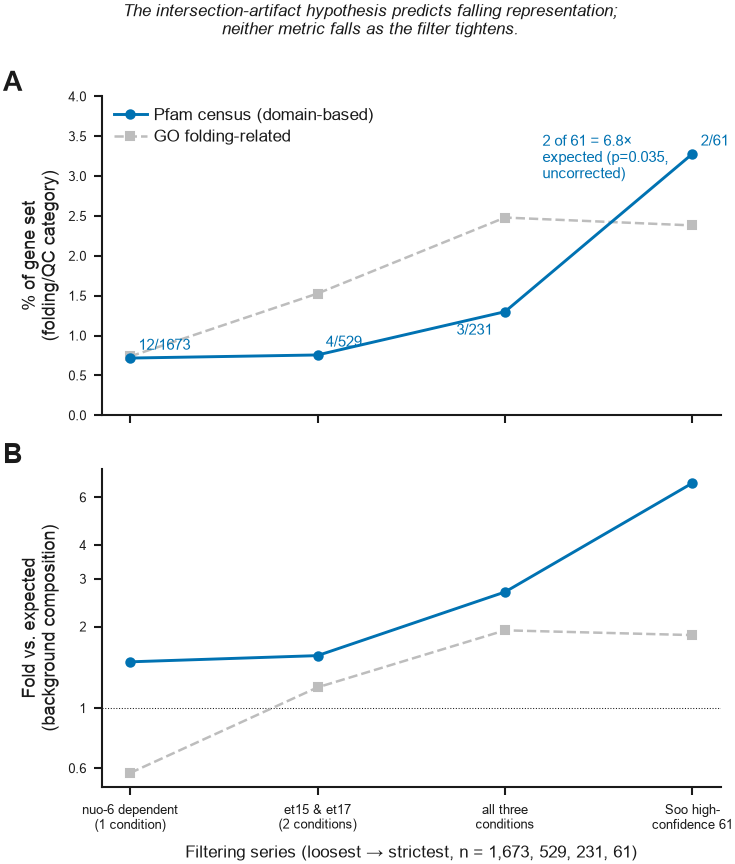

In [5]:
# Draw. Panel A: % of each filter stage that is folding-related, both metrics -
# Pfam census (primary, domain-based, independent of GO) rises monotonically;
# GO folding-related (secondary) moves within noise rather than falling. Either
# reading rejects the intersection-artifact hypothesis, which predicted a fall.
# Panel B: the same walk as fold-enrichment over what background composition alone
# would predict, log-scaled since the census fold at the strict end (6.8x) dwarfs
# the loose end (1.5x).
x = np.arange(len(STAGE_LABELS))
fig, axes = plt.subplots(2, 1, figsize=(THREEQ_W, THREEQ_W * 1.15), sharex=True)

ax = axes[0]
ax.plot(x, census_walk["pct"], "-o", color=BLUE, ms=4, lw=1.4, zorder=3, label="Pfam census (domain-based)")
ax.plot(x, go_walk["pct"], "--s", color=GREY, ms=3.5, lw=1.2, zorder=2, label="GO folding-related")
N_LABEL_OFFSETS = {0: (4, 4), 1: (4, 4), 2: (-6, -11), 3: (4, 4)}
N_LABEL_HA = {0: "left", 1: "left", 2: "right", 3: "left"}
for xi, row in census_walk.iterrows():
    # Point 2's default upper-right placement sat directly on the steep segment
    # rising into point 3 - caught by inspecting the rendered figure, not by
    # anything the code itself flagged. Moved below-left of its marker instead.
    ax.annotate(f"{row['obs']:.0f}/{row['tested']:.0f}", (xi, row["pct"]),
                textcoords="offset points", xytext=N_LABEL_OFFSETS[xi],
                ha=N_LABEL_HA[xi], fontsize=7, color=BLUE)
ax.annotate("2 of 61 = 6.8×\nexpected (p=0.035,\nuncorrected)", (3, census_walk["pct"].iloc[3]),
            textcoords="offset points", xytext=(-72, -2), fontsize=7, color=BLUE,
            ha="left", va="center")
ax.set_ylabel("% of gene set\n(folding/QC category)", fontsize=8.5)
ax.set_ylim(0, 4.0)
panel_label(ax, "A")
ax.legend(loc="upper left", frameon=False, fontsize=8, handletextpad=0.4)

ax2 = axes[1]
ax2.axhline(1, color=INK, lw=0.5, ls=":", zorder=1)
ax2.plot(x, census_walk["fold"], "-o", color=BLUE, ms=4, lw=1.4, zorder=3)
ax2.plot(x, go_walk["fold"], "--s", color=GREY, ms=3.5, lw=1.2, zorder=2)
ax2.set_yscale("log")
# Plain numbers on the log axis. Matplotlib's default renders these as "6 x 10^0",
# "4 x 10^0" and so on, which is correct but not how a fold-change axis is written.
ax2.set_yticks([0.6, 1, 2, 3, 4, 6])
ax2.set_yticklabels(["0.6", "1", "2", "3", "4", "6"])
ax2.minorticks_off()
ax2.set_ylabel("Fold vs. expected\n(background composition)", fontsize=8.5)
ax2.set_xticks(x)
ax2.set_xticklabels(STAGE_LABELS, fontsize=8)
for label, tested in zip(ax2.get_xticklabels(), census_walk["tested"]):
    pass
ax2.set_xlabel("Filtering series (loosest → strictest, n = " +
               ", ".join(f"{int(t):,}" for t in census_walk["tested"]) + ")", fontsize=8, labelpad=6)
panel_label(ax2, "B")

for a in axes:
    a.tick_params(labelsize=6)
    for spine in ("top", "right"):
        a.spines[spine].set_visible(False)

fig.text(0.5, 0.995, "The intersection-artifact hypothesis predicts falling representation;\nneither metric falls as the filter tightens.",
          ha="center", va="top", fontsize=8, color=INK, style="italic")
fig.tight_layout(rect=[0, 0, 1, 0.94])
save(fig, "figure3_filtering_series")
plt.show()